In [1]:
import numpy as np 
import pandas as pd 
import re 

In [2]:
movies_df = pd.read_csv(
    "../3.outputs/movies_processed.csv"
)

ratings_df = pd.read_csv(
    "../3.outputs/ratings_processed_main.csv",
    parse_dates=['rating_date']
)

tags_df = pd.read_csv(
    "../3.outputs/tags_processed.csv",
    parse_dates=['tag_date']
)

In [5]:
movies_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86537 entries, 0 to 86536
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   movieid       86537 non-null  int64
 1   title         86537 non-null  str  
 2   genres        86537 non-null  str  
 3   release_year  86537 non-null  int64
dtypes: int64(2), str(2)
memory usage: 5.8 MB


In [6]:
ratings_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33832162 entries, 0 to 33832161
Data columns (total 4 columns):
 #   Column       Dtype         
---  ------       -----         
 0   userid       int64         
 1   movieid      int64         
 2   rating       float64       
 3   rating_date  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 1.0 GB


In [7]:
tags_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2328315 entries, 0 to 2328314
Data columns (total 4 columns):
 #   Column    Dtype         
---  ------    -----         
 0   userid    int64         
 1   movieid   int64         
 2   tag       str           
 3   tag_date  datetime64[us]
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 96.0 MB


# Popularity-Based Recommendation

In [8]:
movie_stats = ratings_df.groupby('movieid').agg(
    rating_count = ('rating','count'),
    avg_rating = ('rating','mean'),
                    ).reset_index()

In [9]:
movie_stats

,movieid,rating_count,avg_rating
0,1,76813,3.893508
1,2,30209,3.278179
2,3,15820,3.171271
3,4,3028,2.868395
4,5,15801,3.076957
...,...,...,...
83234,288967,1,3.500000
83235,288971,1,0.500000
83236,288975,1,4.000000
83237,288977,1,3.000000


In [10]:
movie_stats = movie_stats.merge(
    movies_df[['movieid','title']],
    on= 'movieid'
)

In [11]:
movie_stats

,movieid,rating_count,avg_rating,title
0,1,76813,3.893508,Toy Story (1995)
1,2,30209,3.278179,Jumanji (1995)
2,3,15820,3.171271,Grumpier Old Men (1995)
3,4,3028,2.868395,Waiting to Exhale (1995)
4,5,15801,3.076957,Father of the Bride Part II (1995)
...,...,...,...,...
83234,288967,1,3.500000,State of Siege: Temple Attack (2021)
83235,288971,1,0.500000,Ouija Japan (2021)
83236,288975,1,4.000000,The Men Who Made the Movies: Howard Hawks (1973)
83237,288977,1,3.000000,Skinford: Death Sentence (2023)


In [12]:
movie_stats['rating_count'].describe()

count     83239.000000
mean        406.446041
std        2806.975876
min           1.000000
25%           2.000000
50%           5.000000
75%          26.000000
max      122296.000000
Name: rating_count, dtype: float64

In [13]:
movie_stats['rating_count'].quantile([0.80,0.85,0.90, 0.95, 0.99])

0.80       46.00
0.85       95.00
0.90      263.00
0.95     1146.00
0.99    10068.96
Name: rating_count, dtype: float64

In [14]:
movie_stats = movie_stats[
    movie_stats['rating_count'] >= 263
]

movie_stats = movie_stats.sort_values(
    by=['avg_rating', 'rating_count'],
    ascending=False
)

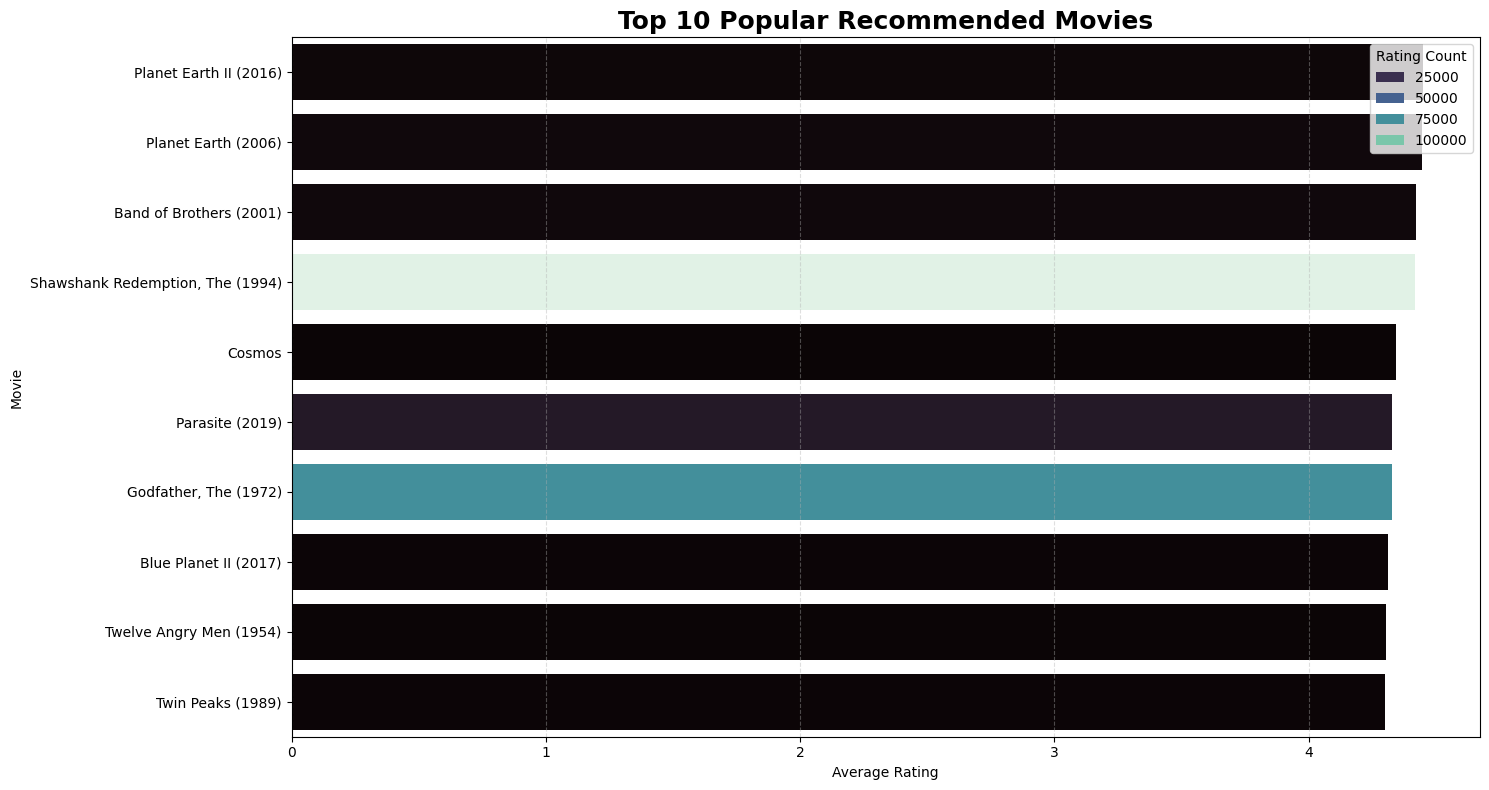

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = movie_stats.head(10)

plt.figure(figsize=(15, 8))

sns.barplot(
    data=top10,
    y='title',
    x='avg_rating',
    hue='rating_count',
    dodge=False,
    palette='mako'
)

plt.title('Top 10 Popular Recommended Movies', fontsize=18, fontweight='bold')
plt.xlabel('Average Rating')
plt.ylabel('Movie')

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.legend(title='Rating Count')
plt.tight_layout()
plt.show()

In [16]:
def recommend_popular(n=10):
    return movie_stats[
        ['title', 'avg_rating', 'rating_count']
    ].head(n)

In [17]:
recommend_popular(10)

,title,avg_rating,rating_count
44214,Planet Earth II (2016),4.451739,2041
39322,Planet Earth (2006),4.448093,3015
44066,Band of Brothers (2001),4.423986,2835
314,"Shawshank Redemption, The (1994)",4.416792,122296
44440,Cosmos,4.343200,625
58750,Parasite (2019),4.329946,12399
840,"Godfather, The (1972)",4.326603,75004
47999,Blue Planet II (2017),4.312944,1267
65984,Twelve Angry Men (1954),4.305723,332
56804,Twin Peaks (1989),4.302562,1132


In [18]:
top10 = movie_stats[
    ['title', 'avg_rating', 'rating_count']
].head(10)

top10.to_csv(
    "../3.outputs/popularity_based_recommendation.csv",
    index=False
)

## Popularity-Based Recommendation System

- Calculated average rating and rating count for each movie.
- Applied a minimum rating threshold of 263 ratings (90th percentile).
- Ranked movies based on average rating.
- Generated Top 10 movie recommendations.

Limitations:
- Same recommendations are shown to every user.
- User preferences are not considered.
- Cannot recommend niche movies.

In [19]:
movies_df.columns

Index(['movieid', 'title', 'genres', 'release_year'], dtype='str')

In [20]:
tags_df[tags_df['tag'].isna()]

,userid,movieid,tag,tag_date
678937,127778,281500,NaN,2022-12-13 20:05:04


In [21]:
tags_df = tags_df.dropna(subset=['tag'])

In [22]:
tags_grouped = (
    tags_df
    .groupby('movieid')['tag']
    .apply(lambda x: ' '.join(x.astype(str)))
    .reset_index()
)

In [23]:
movies_content = movies_df.merge(
    tags_grouped,
    on='movieid',
    how='left'
)

movies_content['tag'] = movies_content['tag'].fillna('')

movies_content['content'] = (
    movies_content['genres'] + ' ' +
    movies_content['tag']
)

In [24]:
movies_content.head()

,movieid,title,genres,release_year,tag,content
0,160838,Into a Dream (2005),drama,2005,,drama
1,161760,Basta Poco (2015),comedy,2015,,comedy
2,162952,The Ox (1991),drama,1991,poverty sweden sven_nykvist,drama poverty sweden sven_nykvist
3,163118,XOXO (2016),drama,2016,aesthetic electronic_music feel-good predictab...,drama aesthetic electronic_music feel-good pre...
4,163362,Dixie (1943),comedy,1943,biography crisis minstrel_show musical quandry...,comedy biography crisis minstrel_show musical ...


In [25]:
## text cleaning 
movies_content['content'] = (
    movies_content['content']
    .str.replace('_', ' ', regex=False)
)
## removiing speacial charchters 
movies_content['content'] = (
    movies_content['content']
    .str.replace(r'[^a-zA-Z\s]', ' ', regex=True)
)
## remove extra space 
movies_content['content'] = (
    movies_content['content']
    .str.replace(r'\s',' ',regex=True)
    .str.strip()
)
## some unwanted pattern removal 
movies_content['content'] = (
    movies_content['content']
    .str.replace(r'\bunknown\b', '', regex=True)
    .str.replace(r'\bbd\b', '', regex=True)
    .str.replace(r'\br\b', '', regex=True)
)
## single word noise
movies_content['content'] = (
    movies_content['content']
    .str.replace(r'\b[a-zA-Z]\b','',regex = True)
)
## remove repeting noise
movies_content['content'] = (
    movies_content['content']
    .str.replace(r'\b([a-z])\1{3,}\b', '', regex=True)
)

ArrowInvalid: Invalid regular expression: invalid escape sequence: \1

# Complete Content-Based Recommendation Training
## Using TF-IDF,CountVectorizer & Cosine Similarity 

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Model 1: TF-IDF + Cosine Similarity (MAIN MODEL)

In [29]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=4000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    lowercase=True
)

tfidf_matrix = tfidf.fit_transform(
    movies_content['content']
)

print(f'TF-IDF Matrix Shape: {tfidf_matrix.shape}')

TF-IDF Matrix Shape: (86537, 4000)


In [30]:
indices = pd.Series(
    movies_content.index,
    index=movies_content['title']
).drop_duplicates()
## TF-IDF only takes input as indexs not as a full name so we have to provide the index to every movie name 

In [31]:
def get_recommendations_tfidf(movie_title, n=10):
    try:
        idx = indices[movie_title]
    except KeyError:
        return f"Movie not found: {movie_title}"
    # Compute similarity only for the selected movie
    sim_scores = cosine_similarity(
        tfidf_matrix[idx:idx+1],
        tfidf_matrix
    ).flatten()

    # Get top similar movies
    sim_indices = sim_scores.argsort()[::-1][1:n+1]

    recommendations = movies_content.iloc[
        sim_indices
    ][['title', 'genres']].copy()

    recommendations['similarity_score'] = (
        sim_scores[sim_indices]
    )

    return recommendations

## Test 

In [32]:
test_movie = 'Interstellar (2014)'

recommendations = get_recommendations_tfidf(
    test_movie,
    10
)

print(recommendations)

                                              title                genres  \
27762                      The Time Guardian (1987)                sci-fi   
2582          2010: The Year We Make Contact (1984)                sci-fi   
61871                                  Tenet (2020)       action,thriller   
35639                              Space Cop (2016)  action,comedy,sci-fi   
57607           The Search for Life in Space (2016)           documentary   
52168                             Hyperlight (2018)                sci-fi   
1899                                 Contact (1997)          drama,sci-fi   
65997                                 Breach (2020)         action,sci-fi   
41850  Science Fiction Volume One: The Osiris Child                sci-fi   
54412                    The Wandering Earth (2019)                sci-fi   

       similarity_score  
27762          0.532486  
2582           0.485365  
61871          0.471515  
35639          0.470378  
57607          0.45519

In [33]:
# Train Count Vectorizer
count_vect = CountVectorizer(
    stop_words='english',
    max_features=4000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    lowercase=True
)

count_matrix = count_vect.fit_transform(movies_content['content'])

print(f'Count Vectorizer Matrix Shape: {count_matrix.shape}')

Count Vectorizer Matrix Shape: (86537, 4000)


In [34]:
def get_recommendations_count_vec(movie_title, n=10):
    try:
        idx = indices[movie_title]
    except KeyError:
        return f"Movie not found: {movie_title}"
    # Compute similarity only for the selected movie
    sim_scores = cosine_similarity(
        count_matrix[idx:idx+1],
        count_matrix
    ).flatten()

    # Get top similar movies
    sim_indices = sim_scores.argsort()[::-1][1:n+1]

    recommendations = movies_content.iloc[
        sim_indices
    ][['title', 'genres']].copy()

    recommendations['similarity_score'] = (
        sim_scores[sim_indices]
    )

    return recommendations

## Save All Trained Models

In [35]:
model_data = {
    'tfidf_matrix': tfidf_matrix,
    'indices': indices,
    'movies_content': movies_content
}

In [36]:
import pickle
import os

os.makedirs('../4.models', exist_ok=True)

with open('../4.models/movie_content_recommender.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Model saved successfully!")

Model saved successfully!


# Content-Based Recommendation System Summary

## Objective

The goal of this model is to recommend movies based on their content rather than overall popularity or user behavior. The model uses movie genres and user-generated tags to identify movies with similar characteristics.

## Data Used

### Movies Dataset

- Movie Title
- Genres
- Release Year

### Tags Dataset

- User-generated movie tags

## Feature Engineering

A `content` column was created by combining:

- Genres
- Tags

Text preprocessing included:

- Converting text to lowercase
- Removing unnecessary symbols and noise words
- Cleaning extra spaces
- Creating a unified content representation for each movie

## TF-IDF Vectorization

TF-IDF (Term Frequency-Inverse Document Frequency) was used to convert movie content into numerical vectors.

### Configuration

- `max_features = 4000`
- `min_df = 5`
- `max_df = 0.8`
- `ngram_range = (1, 2)`
- `stop_words = 'english'`

### Final TF-IDF Matrix Shape

- 86,537 movies
- 4,000 content features

## Similarity Calculation

Cosine Similarity was used to measure the similarity between movies.

Due to memory limitations, a full similarity matrix was not generated. Instead, similarity scores were computed dynamically whenever recommendations were requested.

This approach significantly reduced memory usage while maintaining recommendation quality.

## Model Comparison

Two content-based recommendation approaches were tested:

### 1. TF-IDF + Cosine Similarity

**Advantages:**

- Gives higher importance to informative terms
- Reduces the influence of very common words
- Widely used in recommendation systems

### 2. Count Vectorizer + Cosine Similarity

**Advantages:**

- Simpler implementation
- Uses raw term frequencies

## Results

Both TF-IDF and Count Vectorizer produced highly similar recommendations across multiple test movies.

### Movies Tested

- The Shawshank Redemption
- Interstellar
- The Dark Knight

The average recommendation ratings were nearly identical for both approaches.

Therefore, **TF-IDF** was selected as the final content-based recommendation model because it provides better feature weighting while maintaining similar recommendation quality.

## Conclusion

The content-based recommendation system successfully recommends movies with similar genres and tags.

The final model uses:

- TF-IDF Vectorization
- Cosine Similarity

The trained recommendation model was saved for deployment in the Streamlit application.



# Collaborative Filtering Recommendation System

## Objective

The goal of collaborative filtering is to recommend movies based on user behavior rather than movie content.

Unlike the content-based model, collaborative filtering learns patterns from user ratings and identifies similarities between users and movies.

This approach can recommend movies that users with similar preferences have enjoyed, even when the movies do not share similar genres or tags.

In this section, a collaborative filtering model will be built using the MovieLens ratings dataset and evaluated using recommendation system metrics.

### Imports

In [4]:
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse, mae

## Collaborative Filtering

Collaborative filtering recommends movies based on user rating patterns rather than movie content.

Unlike the content-based approach, collaborative filtering learns relationships between users and movies from historical ratings data.

The Surprise library was used because it provides efficient implementations of collaborative filtering algorithms such as SVD and KNN without requiring a large user-movie matrix in memory.

In [35]:
# Create Surprise Dataset
reader = Reader(
    rating_scale=(0.5, 5.0)
)

data = Dataset.load_from_df(
    ratings_df[['userid', 'movieid', 'rating']],
    reader
)

In [36]:
# Train-Test Split
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [37]:
print("Training ratings:", trainset.n_ratings)
print("Testing ratings:", len(testset))

Training ratings: 27065729
Testing ratings: 6766433


In [ ]:
import os
import joblib
reader = Reader(rating_scale=(0.5, 5.0))

data = Dataset.load_from_df(
    ratings[["userid", "movieid", "rating"]],
    reader
)

trainset = data.build_full_trainset()

svd = SVD(
    n_factors=50,
    n_epochs=10,
    random_state=42
)

svd.fit(trainset)

joblib.dump(
    svd,
    r"4.models\collaborative_filtering_svd.pkl"
)

In [38]:
# Train First SVD Model
svd_model = SVD(random_state=42)
svd_model.fit(trainset)

In [39]:
# Predictions
predictions = svd_model.test(testset)

In [40]:
from surprise.accuracy import rmse, mae

rmse_score = rmse(predictions)
mae_score = mae(predictions)

RMSE: 0.7858
MAE:  0.5890


In [41]:
train_predictions = svd_model.test(
    trainset.build_testset()
)

train_rmse = rmse(
    train_predictions,
    verbose=False
)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE : {rmse_score:.4f}")

Train RMSE: 0.6766
Test RMSE : 0.7858


In [48]:
import os
import joblib

os.makedirs('../4.models', exist_ok=True)

joblib.dump(
    svd_model,
    '../4.models/collaborative_filtering_svd.pkl'
)

print("Model saved successfully!")

Model saved successfully!


In [7]:
# Taking small dataset so the streamlit will work 

# Take sample for deployment model
ratings_sample = ratings_df.sample(
    n=1000000,
    random_state=42
)

# Create Surprise Dataset
reader = Reader(
    rating_scale=(0.5, 5.0)
)

data = Dataset.load_from_df(
    ratings_sample[['userid', 'movieid', 'rating']],
    reader
)
trainset = data.build_full_trainset()

svd_model = SVD(
    n_factors=50,
    n_epochs=10,
    random_state=42
)

svd_model.fit(trainset)

In [8]:
import joblib

joblib.dump(
    svd_model,
    "../4.models/collaborative_filtering_svd.pkl",
    compress=3
)

['../4.models/collaborative_filtering_svd.pkl']